In [ ]:
# necessary imports 
import qiskit as qsk
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
import numpy as np 

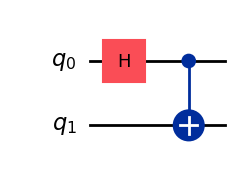

In [3]:
# generate the phi state for the circuit 
circ = QuantumCircuit(2)
circ.h(0)
circ.cx(0, 1)
circ.draw('mpl')

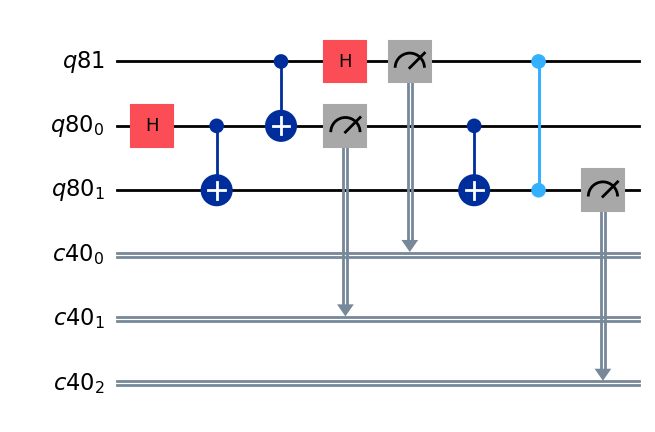

In [224]:
# test the quantum teleportation circuit 


alice_bob = QuantumRegister(2)
transp = QuantumRegister(1)
measurables = ClassicalRegister(3)
circ = QuantumCircuit(transp, alice_bob, measurables)

(q0, q1) = alice_bob
(q2, ) = transp
(c0, c1, c2) = measurables

# init bell state (phi+)
# circ.x(0)
circ.h(1)
circ.cx(1, 2)

# code the teleport protocol
circ.cx(0, 1)
circ.h(0)

circ.measure([q0, q2], [c1, c0])

# conditional applying gates on the qbit of Bob
# with circ.if_test((c1, 0)):
#     circ.x(2)

# with circ.if_test((c0, 0)):
#     circ.z(2)

circ.cx(1, 2)
circ.cz(0, 2)
circ.measure(q1, c2)
circ.draw('mpl', cregbundle=False)

In [238]:
# simulating and extracting the values 
simulator = AerSimulator()
transpiled_circ = qsk.transpile(circ, simulator)

results = simulator.run(transpiled_circ, shots=1).result()

counts = results.get_counts()
print(counts)
print(results)

{'011': 1}
Result(backend_name='aer_simulator', backend_version='0.17.1', job_id='f4fbc2ba-f906-4134-b630-ba92a41b7869', success=True, results=[ExperimentResult(shots=1, success=True, meas_level=2, data=ExperimentResultData(counts={'0x3': 1}), header={'creg_sizes': [['c40', 3]], 'global_phase': 0.0, 'memory_slots': 3, 'n_qubits': 3, 'name': 'circuit-2099', 'qreg_sizes': [['q81', 1], ['q80', 2]], 'metadata': {}}, status=DONE, seed_simulator=1084330867, metadata={'time_taken': 0.000180338, 'num_bind_params': 1, 'parallel_state_update': 16, 'required_memory_mb': 0, 'input_qubit_map': [[2, 2], [1, 1], [0, 0]], 'method': 'stabilizer', 'device': 'CPU', 'num_qubits': 3, 'active_input_qubits': [0, 1, 2], 'num_clbits': 3, 'remapped_qubits': False, 'parallel_shots': 1, 'runtime_parameter_bind': False, 'max_memory_mb': 27865, 'noise': 'ideal', 'measure_sampling': False, 'batched_shots_optimization': False, 'fusion': {'enabled': False}}, time_taken=0.000180338)], date=2025-11-19T20:13:56.867292, s

In [ ]:
def gen_quant_circ(bit_val: int):
    alice_bob = QuantumRegister(2)
    transp = QuantumRegister(1)
    measurable = ClassicalRegister(3)
    circ = QuantumCircuit(transp, alice_bob, measurable)


The final state of qubit 2 is: 100


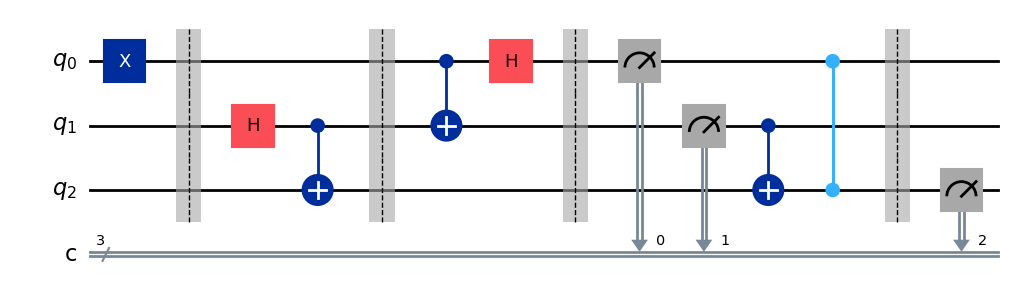

In [249]:
# better and pratical 

qc = QuantumCircuit(3, 3)

qc.x(0)
qc.barrier()

qc.h(1)
qc.cx(1, 2)
qc.barrier()

qc.cx(0, 1)
qc.h(0)
qc.barrier()

qc.measure(0, 0)
qc.measure(1, 1)

qc.cx(1, 2)
qc.cz(0, 2)

qc.barrier()

qc.measure(2, 2)


simul = AerSimulator()

transpiled_circ = qsk.transpile(qc, simul)
job = simul.run(transpiled_circ, shot=1, memory = True)
result = job.result()
counts  = result.get_counts()

memory = result.get_memory(transpiled_circ)[0] 
print(f"The final state of qubit 2 is: {memory}")
qc.draw('mpl')

In [22]:
def send_bit_info(bit: int):
    # DEFINE THE QUANTUM TELEPORTATION PROTOCOL CIRCUIT  
    circuit = QuantumCircuit(3, 3)
    # prepare the qubit[index: 0] to be sent 
    if bit == 1:
        circuit.x(0)
    circuit.barrier()
    # prepare the entangled phi state of the qbits of Alice and Bob
    circuit.h(1)
    circuit.cx(1, 2)
    circuit.barrier()

    # execute the teleportation
    circuit.cx(0, 1)
    circuit.h(0)
    # measure the qbits (we measure the alice's one and the one we want to send)
    circuit.measure(0, 0)
    circuit.measure(1, 1)
    # after the measurement apply the cx and cz gates on the bob's qbit depending on the results yeild by the 
    # 2 measurements from above 
    circuit.cx(1, 2)
    circuit.cz(0, 2)
    circuit.barrier()
    # lastly measure the qbit of bob 
    circuit.measure(2, 2)

    # simulate the circuit 
    simulator = AerSimulator()
    transpiled_circuit = qsk.transpile(circuit, simulator)
    result = simulator.run(transpiled_circuit, shot=1, memory = True).result()
    counts = result.get_memory(transpiled_circuit)[0]
    return counts[0]


# proof that the comunication protocol works 
random_choices = [] 
bobs_bits = []
for i in range(100):
    random_bit = np.random.choice([0, 1])
    random_choices.append(random_bit)
    bobs_bit = send_bit_info(random_bit)
    bobs_bits.append(int(bobs_bit))

count = 0
for i in range(100):
    if random_choices[i] == bobs_bits[i]:
        count+=1 

print(count == 100) 

True


In [38]:
# showcase the latency of the algorithm 
import time 

num_repetitions = [1, 10, 100, 1000, 10000]
time_spent = []

for num_repetition in num_repetitions:
  
    count = 0
    start_timestamp = time.time()
    for i in range(num_repetition):
        random_bit = np.random.choice([0, 1])
        bobs_bit = send_bit_info(random_bit)
        if random_bit == int(bobs_bit):
            count += 1
    end_timestamp = time.time()
    
    print(f"Time taken for the {i} repetitions: {end_timestamp - start_timestamp}\n and the number of correct bits is: {count}")
    


Time taken for the 0 repetitions: 0.20719242095947266
 and the number of correct bits is: 1
Time taken for the 9 repetitions: 1.3957490921020508
 and the number of correct bits is: 10
Time taken for the 99 repetitions: 12.09362506866455
 and the number of correct bits is: 100
Time taken for the 999 repetitions: 122.9063971042633
 and the number of correct bits is: 1000
Time taken for the 9999 repetitions: 1219.1246724128723
 and the number of correct bits is: 10000
